# The U-Net for noise prediction

In a diffusion model, the neural network's job is to predict the noise $\epsilon$ that was added to a clean image $x_0$ to produce the noisy $x_t$. Given that prediction, we can iteratively denoise: starting from pure Gaussian noise $x_T$ and stepping backward, we generate samples that resemble the training data.

The network needs three properties to do this well:

1. **Spatial reasoning across scales.** Noise at different spatial frequencies needs to be predicted differently — fine textures vs. overall shape. A U-Net handles this naturally via its down–up architecture with skip connections.
2. **Time awareness.** The same image at $t = 10$ (slightly noisy) and $t = 190$ (very noisy) should be denoised very differently. The network must be conditioned on $t$ — this is what time embeddings provide.
3. **Stable training at depth.** Diffusion models need many ResNet-style blocks. We follow the DDPM convention of GroupNorm + SiLU activations throughout.

This notebook builds the U-Net incrementally:

1. Sinusoidal time embeddings.
2. Residual block with time conditioning.
3. Downsample / upsample helpers.
4. Full U-Net assembly.
5. Sanity-check forward pass.

*Reference: Ho, Jain, Abbeel — Denoising Diffusion Probabilistic Models (2020), [arXiv:2006.11239](https://arxiv.org/abs/2006.11239).*

## 1. Sinusoidal time embeddings

The U-Net takes a scalar timestep $t \in \{0, 1, \dots, T-1\}$ as conditioning. A learned embedding table works but doesn't generalize to unseen timesteps; sinusoidal embeddings — the same construction used for positional encoding in Transformers — give each timestep a unique, smoothly varying vector representation without learned parameters.

For an embedding dimension $d$, the embedding for timestep $t$ is

$$
\text{TE}(t, 2i)   = \sin(t \cdot \omega_i), \qquad
\text{TE}(t, 2i+1) = \cos(t \cdot \omega_i),
$$

where $\omega_i = 10000^{-2i/d}$ are log-spaced frequencies. Low-index dimensions oscillate quickly with $t$ (encoding small differences between nearby timesteps), high-index dimensions oscillate slowly (encoding the broad position of $t$ within the schedule).

The visualization below should show fast oscillations in some rows and slow ones in others — the classic Transformer positional-encoding stripe pattern.

Time embedding output shape: torch.Size([200, 64])


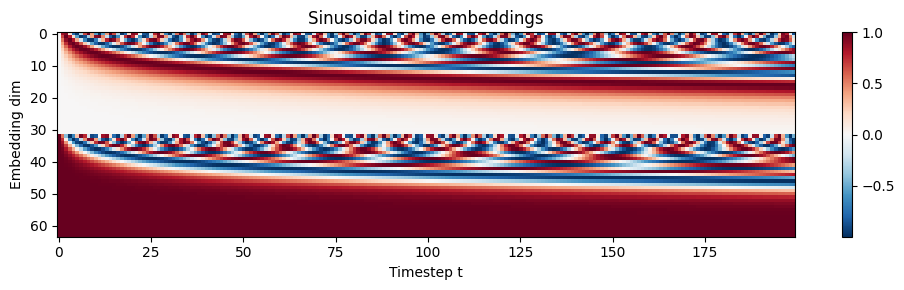

In [2]:
import math
import torch

import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Sinusoidal time embedding
# ----------------------------------------------------------------------------
# Maps a scalar timestep t to a vector embedding, same idea as positional
# encoding in Transformers. The diffusion U-Net needs this so each layer
# can condition on "how noisy is x_t".

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        # t : tensor of shape (B,) with int or float timesteps
        device = t.device
        half_dim = self.dim // 2
        # frequencies log-spaced from 1 down to 1/10000
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        # broadcast: (B, 1) * (1, half_dim) -> (B, half_dim)
        emb = t[:, None].float() * emb[None, :]
        # interleave sin and cos
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)  # (B, dim)
        return emb


# Sanity check + visualize
embed = SinusoidalTimeEmbedding(dim=64)
t = torch.arange(0, 200)
out = embed(t)
print(f"Time embedding output shape: {out.shape}")   # expect torch.Size([200, 64])

plt.figure(figsize=(10, 3))
plt.imshow(out.T.detach().numpy(), aspect="auto", cmap="RdBu_r")
plt.xlabel("Timestep t")
plt.ylabel("Embedding dim")
plt.title("Sinusoidal time embeddings")
plt.colorbar()
plt.tight_layout()
plt.show()

## 2. Residual block with time conditioning

The basic computational unit of the U-Net. The forward pass goes:

`x → GroupNorm → SiLU → Conv3×3`, then add the projected time embedding, then `GroupNorm → SiLU → Conv3×3`, then add the residual `skip(x)`.

A few design choices worth noting:

- **GroupNorm over BatchNorm.** Diffusion models train with relatively small per-device batches and benefit from a batch-independent normalization.
- **SiLU activation** ($x \cdot \sigma(x)$). Standard in DDPM; gives smoother gradients than ReLU at no extra cost.
- **Time injection between the two convs**, not at the input. This is the original DDPM pattern and lets the time signal modulate intermediate features rather than just the raw input.
- **Skip connection** uses a 1×1 conv when input and output channel counts differ, identity otherwise.

In [3]:
# Residual block with time injection
# ----------------------------------------------------------------------------
# The basic computational unit of the U-Net.
#  - Two conv layers, GroupNorm + SiLU activation (DDPM convention)
#  - Time embedding projected and added between the two convs
#  - Skip connection (identity if channels match, 1x1 conv otherwise)

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, num_groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        
        self.norm2 = nn.GroupNorm(num_groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        
        # Skip path: identity if channel count matches, otherwise 1x1 conv
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()
    
    def forward(self, x, t_emb):
        # x     : (B, C_in, H, W)
        # t_emb : (B, time_emb_dim)
        
        h = self.conv1(F.silu(self.norm1(x)))                # (B, C_out, H, W)
        # project time embedding to (B, C_out) and broadcast over spatial dims
        h = h + self.time_mlp(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))                # (B, C_out, H, W)
        return h + self.skip(x)


# Sanity check: shapes go in, shapes come out
B, C_in, H, W = 4, 32, 16, 16
time_emb_dim = 64

block = ResBlock(in_channels=C_in, out_channels=64, time_emb_dim=time_emb_dim)
x = torch.randn(B, C_in, H, W)
t_emb = torch.randn(B, time_emb_dim)

y = block(x, t_emb)
print(f"Input  shape: {x.shape}")     # expect (4, 32, 16, 16)
print(f"Output shape: {y.shape}")     # expect (4, 64, 16, 16)

Input  shape: torch.Size([4, 32, 16, 16])
Output shape: torch.Size([4, 64, 16, 16])


## 3. Downsampling and upsampling

The U-Net moves between spatial resolutions multiple times. We use simple variants:

- **Downsample**: a stride-2 3×3 convolution. Halves $H$ and $W$, keeps channel count (channel growth happens inside the next ResBlock).
- **Upsample**: nearest-neighbor 2× interpolation followed by a 3×3 convolution. Doubles $H$ and $W$. The conv is there to clean up checkerboard artifacts that pure transposed convolutions can introduce.

In [4]:
# Down / up sampling
# ----------------------------------------------------------------------------
# Downsample : stride-2 conv (halves H, W; keeps channels)
# Upsample   : nearest-neighbor 2x interpolation followed by a 3x3 conv

class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)
    
    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
    
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)

## 4. Full U-Net assembly

The architecture has three parts:

1. **Down path** — progressively halves spatial resolution while increasing channel count. At each level we run a residual block, save the output as a skip connection, then downsample. Channel widths follow `channel_mults`: with `base_channels = 32` and `channel_mults = (1, 2, 4)`, the widths are `[32, 64, 128]`.
2. **Bottleneck** — one extra residual block at the deepest spatial level.
3. **Up path** — mirrors the down path. At each level we upsample, concatenate the corresponding skip from the down path along the channel dimension, then run a residual block.

A 32×32 input flows through the network like this:

```
(B,1,32,32)
  → init_conv         → (B,32,32,32)
  → down0  + skip0    → (B,32,32,32)
  → downsample        → (B,32,16,16)
  → down1  + skip1    → (B,64,16,16)
  → downsample        → (B,64,8,8)
  → down2 (bottleneck)→ (B,128,8,8)
  → mid_block         → (B,128,8,8)
  → upsample          → (B,128,16,16)
  → concat skip1      → (B,192,16,16)
  → up1               → (B,64,16,16)
  → upsample          → (B,64,32,32)
  → concat skip0      → (B,96,32,32)
  → up0               → (B,32,32,32)
  → final_norm/conv   → (B,1,32,32)
```

The output has the same shape as the input — the network predicts noise, which lives in the same image space as $x_t$.

In [5]:
# U-Net
# ----------------------------------------------------------------------------
# Predicts noise eps given (x_t, t).
# Skip connections concatenate down-path features with up-path features at
# matching resolutions.

class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        base_channels=32,
        channel_mults=(1, 2, 4),
        time_emb_dim=128,
    ):
        super().__init__()
        
        # --- time embedding pipeline ---
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )
        
        # channel count at each level
        channels = [base_channels * m for m in channel_mults]
        # with base=32 and mults=(1,2,4): channels = [32, 64, 128]
        
        # --- initial conv: image -> feature map ---
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        
        # --- down path ---
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        prev_ch = base_channels
        for i, ch in enumerate(channels):
            self.down_blocks.append(ResBlock(prev_ch, ch, time_emb_dim))
            # downsample at every level except the deepest (bottleneck)
            if i < len(channels) - 1:
                self.downsamples.append(Downsample(ch))
            prev_ch = ch
        
        # --- bottleneck ---
        self.mid_block = ResBlock(channels[-1], channels[-1], time_emb_dim)
        
        # --- up path (mirrors down) ---
        self.upsamples = nn.ModuleList()
        self.up_blocks = nn.ModuleList()
        for i in reversed(range(len(channels) - 1)):
            up_ch  = channels[i + 1]   # incoming channels from deeper level
            out_ch = channels[i]       # outgoing channels at this level
            self.upsamples.append(Upsample(up_ch))
            # input to ResBlock = upsampled features + concatenated skip
            self.up_blocks.append(ResBlock(up_ch + out_ch, out_ch, time_emb_dim))
        
        # --- output head ---
        self.final_norm = nn.GroupNorm(8, base_channels)
        self.final_conv = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)
    
    def forward(self, x, t):
        # x : (B, C_in, H, W)
        # t : (B,)
        
        t_emb = self.time_mlp(t)
        
        # initial conv
        x = self.init_conv(x)
        
        # down path, collecting skips
        skips = []
        for i, block in enumerate(self.down_blocks):
            x = block(x, t_emb)
            if i < len(self.downsamples):
                skips.append(x)
                x = self.downsamples[i](x)
        
        # bottleneck
        x = self.mid_block(x, t_emb)
        
        # up path, consuming skips in reverse order
        for up, block in zip(self.upsamples, self.up_blocks):
            x = up(x)
            skip = skips.pop()
            x = torch.cat([x, skip], dim=1)
            x = block(x, t_emb)
        
        # output head
        x = F.silu(self.final_norm(x))
        x = self.final_conv(x)
        return x

## 5. Sanity check

Before we connect this U-Net to the training loop, we verify two things:

1. **Shape preservation.** Input $(B, 1, 32, 32)$ should come out as $(B, 1, 32, 32)$. Any mismatch — wrong channel count, spatial dimension halving instead of doubling, off-by-one in the skip indexing — means there's a wiring bug we want to catch now, not during training.
2. **Parameter count.** Around one million parameters is the right ballpark for MNIST. Much smaller and the model will underfit; much larger and we are wasting compute on a trivial dataset.

In [6]:
model = UNet(
    in_channels=1,
    base_channels=32,
    channel_mults=(1, 2, 4),
    time_emb_dim=128,
)

B = 4
x = torch.randn(B, 1, 32, 32)
t = torch.randint(0, 200, (B,))

out = model(x, t)

print(f"Input  shape: {x.shape}")    # expect torch.Size([4, 1, 32, 32])
print(f"Output shape: {out.shape}")  # expect torch.Size([4, 1, 32, 32])

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Input  shape: torch.Size([4, 1, 32, 32])
Output shape: torch.Size([4, 1, 32, 32])
Total parameters: 1,112,801
